# Лабораторная №3 — Кластеризация (KMeans, DBSCAN, Agglomerative) + PCA-визуализация


In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    silhouette_score,
    confusion_matrix,
    classification_report,
)

from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

RANDOM_STATE = 42
from IPython.display import Markdown, display


## 1) Загрузка данных


In [2]:
DATA_PATH = "https://raw.githubusercontent.com/Torcna/ML-practice-unn/main/spotify_churn_dataset.csv"
TARGET_COL = "is_churned"
ID_COLS = ["user_id"]

def load_table(path: str) -> pd.DataFrame:
    path = str(path)
    if path.lower().endswith(".csv"):
        return pd.read_csv(path, encoding="utf-8")
    if path.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(path)
    if path.lower().endswith(".parquet"):
        return pd.read_parquet(path)
    raise ValueError(f"Unknown file format: {path}")

df = load_table(DATA_PATH)
df.head(15)


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
5,6,Female,17,AU,Free,219,35,0.46,Desktop,13,0,0
6,7,Female,39,UK,Premium,289,44,0.38,Desktop,0,1,0
7,8,Female,41,UK,Free,210,68,0.11,Mobile,5,0,0
8,9,Other,55,DE,Student,50,66,0.29,Web,0,1,0
9,10,Male,44,DE,Free,278,94,0.38,Mobile,44,0,0


In [3]:
print("Размер датасета:", df.shape)
print("Столбцы:", df.columns.tolist())
df.info()


Размер датасета: (8000, 12)
Столбцы: ['user_id', 'gender', 'age', 'country', 'subscription_type', 'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type', 'ads_listened_per_week', 'offline_listening', 'is_churned']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null

## 2) Формирование X и y

`y` используется **только** для оценки после кластеризации.


In [4]:
df = df.copy()

y = df[TARGET_COL].copy() if (TARGET_COL is not None and TARGET_COL in df.columns) else None

drop_cols = []
if TARGET_COL is not None and TARGET_COL in df.columns:
    drop_cols.append(TARGET_COL)
for c in ID_COLS:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols, errors="ignore")

print("Размерность X:", X.shape)
print("Есть ли y:", y is not None)
if y is not None:
    print("Распределение y:")
    display(y.value_counts(dropna=False))


Размерность X: (8000, 10)
Есть ли y: True
Распределение y:


,count
is_churned,
0,5929
1,2071


## 3) Preprocessing

Numeric features -> StandardScaler  
Categorical features -> OneHotEncoder


In [5]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Числовых признаков:", len(numeric_cols))
print("Категориальных признаков:", len(categorical_cols))

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_pre = preprocess.fit_transform(X)
print("После предобработки:", X_pre.shape)


Числовых признаков: 6
Категориальных признаков: 4
После предобработки: (8000, 24)


## 4) PCA for visualization

In [6]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X_pre)

print("PCA shape:", X_pca2.shape)
print("Доля объяснённой дисперсии (2 компоненты):", float(pca_2d.explained_variance_ratio_.sum()))


PCA shape: (8000, 2)
Доля объяснённой дисперсии (2 компоненты): 0.35044946111178116


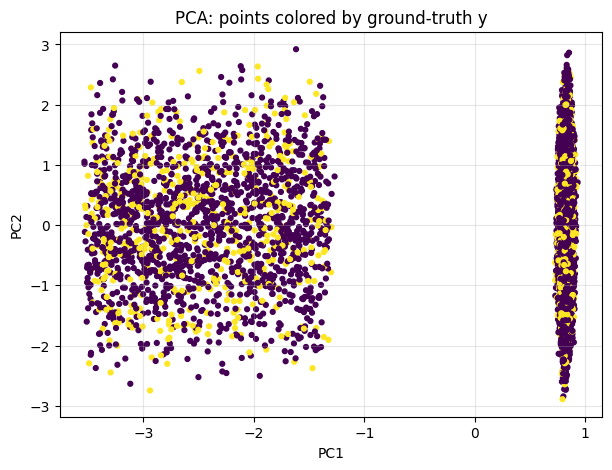

In [7]:
def plot_2d(points_2d: np.ndarray, labels, title: str):
    plt.figure(figsize=(7, 5))
    plt.scatter(points_2d[:, 0], points_2d[:, 1], c=labels, s=12)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.show()

if y is not None:
    plot_2d(X_pca2, y, "PCA: points colored by ground-truth y")


## 5) KMeans

Выбираем лучшее k по silhouette (unsupervised).


Лучшее k по silhouette: 2 score: 0.2578596956138359


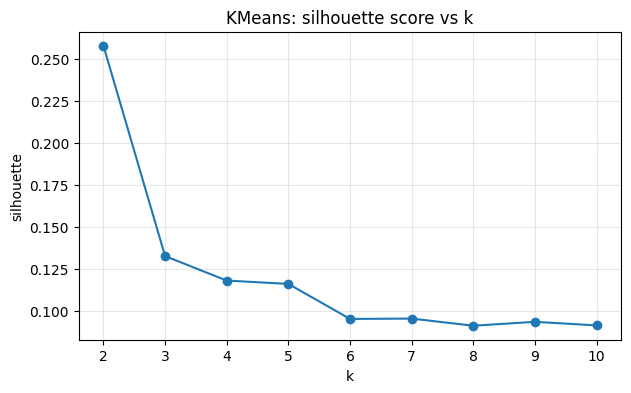

In [8]:
def select_k_by_silhouette(X_matrix, k_min=2, k_max=10, random_state=RANDOM_STATE):
    scores = []
    ks = list(range(k_min, k_max + 1))
    for k in ks:
        model = KMeans(n_clusters=k, n_init="auto", random_state=random_state)
        labels = model.fit_predict(X_matrix)
        if len(set(labels)) <= 1 or len(set(labels)) >= X_matrix.shape[0]:
            scores.append(np.nan)
        else:
            scores.append(silhouette_score(X_matrix, labels))
    best_idx = int(np.nanargmax(scores))
    return ks, scores, ks[best_idx], scores[best_idx]

ks, sil_scores, best_k, best_sil = select_k_by_silhouette(X_pre, 2, 10)
print("Лучшее k по silhouette:", best_k, "score:", float(best_sil))

plt.figure(figsize=(7, 4))
plt.plot(ks, sil_scores, marker="o")
plt.title("KMeans: silhouette score vs k")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.3)
plt.show()


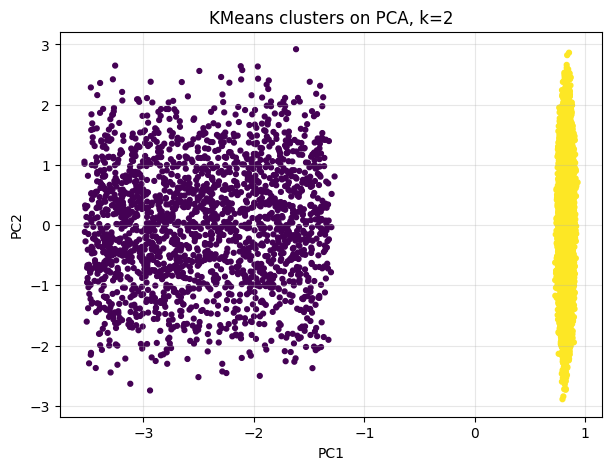

In [9]:
kmeans = KMeans(n_clusters=best_k, n_init="auto", random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X_pre)
plot_2d(X_pca2, labels_kmeans, f"KMeans clusters on PCA, k={best_k}")


**Результат KMeans на PCA (2D).**  
График иллюстрирует, как найденные кластеры выглядят в 2D-проекции PCA. Важно: PCA используется только для визуализации, кластеризация выполняется на полном пространстве признаков `X_pre`.

## 6) DBSCAN

Unsupervised grid search using silhouette score on non-noise points.


In [10]:
def dbscan_grid_search_unsupervised(X_matrix, min_samples_list=(5, 10, 20, 40), eps_percentiles=(80, 85, 90, 92, 95, 97, 99)):
    best = None
    history = []
    for min_samples in min_samples_list:
        nn = NearestNeighbors(n_neighbors=min_samples)
        nn.fit(X_matrix)
        dists, _ = nn.kneighbors(X_matrix)
        kth = np.sort(dists[:, -1])
        for p in eps_percentiles:
            eps = float(np.percentile(kth, p))
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(X_matrix)

            mask = labels != -1
            n_clusters = len(set(labels[mask])) if mask.any() else 0
            noise_frac = 1 - float(mask.mean())

            if mask.sum() < 2 or n_clusters < 2:
                score = np.nan
            else:
                score = float(silhouette_score(X_matrix[mask], labels[mask]))

            history.append(
                {"min_samples": min_samples, "eps": eps, "silhouette": score, "clusters": n_clusters, "noise_frac": noise_frac}
            )

            if not np.isnan(score):
                if best is None or score > best[0]:
                    best = (score, eps, min_samples, labels)

    hist_df = pd.DataFrame(history).sort_values(by="silhouette", ascending=False)
    return best, hist_df

best_db, db_hist = dbscan_grid_search_unsupervised(X_pre)
db_hist.head(10)


,min_samples,eps,silhouette,clusters,noise_frac
8,10,1.914503,0.258563,2,0.011625
9,10,1.964580,0.258273,2,0.004000
5,5,1.897605,0.258209,2,0.002375
14,20,2.069227,0.258200,2,0.010875
10,10,1.989656,0.258160,2,0.002625
21,40,2.237557,0.258151,2,0.003125
22,40,2.276390,0.258083,2,0.001125
11,10,2.039758,0.257958,2,0.000500
16,20,2.146617,0.257946,2,0.000875
17,20,2.171965,0.257943,2,0.000250


**Подбор параметров DBSCAN (без `y`).**  
Параметры `eps` и `min_samples` подбираются по silhouette score на точках, не отнесённых к шуму (`label != -1`).  
Это позволяет сравнивать варианты DBSCAN без использования истинных меток.

Лучшие параметры DBSCAN (без y):
  eps = 1.9145027778734918
  min_samples = 10
  silhouette = 0.2585632257272282
Уникальные метки DBSCAN: [np.int64(-1), np.int64(0), np.int64(1)]
Доля шума DBSCAN: 0.011625


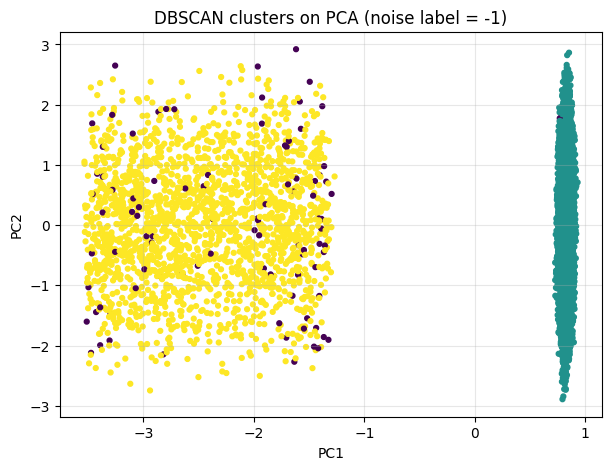

In [12]:
if best_db is None:
    print("DBSCAN did not find a stable clustering")
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    labels_dbscan = dbscan.fit_predict(X_pre)
else:
    best_score, best_eps, best_min_samples, labels_dbscan = best_db
    print("Лучшие параметры DBSCAN (без y):")
    print("  eps =", best_eps)
    print("  min_samples =", best_min_samples)
    print("  silhouette =", float(best_score))

unique_labels = sorted(set(labels_dbscan))
noise_frac = float((np.asarray(labels_dbscan) == -1).mean())
print("Уникальные метки DBSCAN:", unique_labels)
print("Доля шума DBSCAN:", noise_frac)

plot_2d(X_pca2, labels_dbscan, "DBSCAN clusters on PCA (noise label = -1)")


**Результат DBSCAN на PCA (2D).**  
DBSCAN может помечать часть объектов как шум (`label = -1`). Доля шума и число найденных кластеров важны для интерпретации результата.

## 7) AgglomerativeClustering

Select `k` by silhouette score (unsupervised).


Лучшее k (Agglomerative) по silhouette: 2 score: 0.2578596956138359


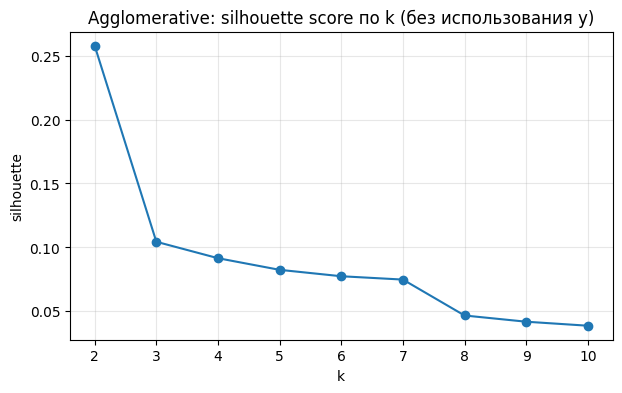

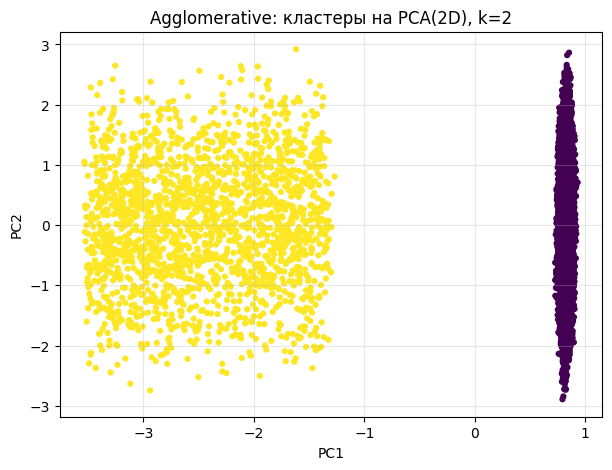

In [13]:
def select_agglom_by_silhouette(X_matrix, k_min=2, k_max=10):
    scores = []
    ks = list(range(k_min, k_max + 1))
    for k in ks:
        model = AgglomerativeClustering(n_clusters=k)
        labels = model.fit_predict(X_matrix)
        if len(set(labels)) <= 1 or len(set(labels)) >= X_matrix.shape[0]:
            scores.append(np.nan)
        else:
            scores.append(float(silhouette_score(X_matrix, labels)))
    best_idx = int(np.nanargmax(scores))
    return ks, scores, ks[best_idx], scores[best_idx]

ks_a, sil_a, best_k_a, best_sil_a = select_agglom_by_silhouette(X_pre, 2, 10)
print("Лучшее k (Agglomerative) по silhouette:", best_k_a, "score:", float(best_sil_a))

plt.figure(figsize=(7, 4))
plt.plot(ks_a, sil_a, marker="o")
plt.title("Agglomerative: silhouette score по k (без использования y)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.3)
plt.show()

aggl = AgglomerativeClustering(n_clusters=best_k_a)
labels_aggl = aggl.fit_predict(X_pre)
plot_2d(X_pca2, labels_aggl, f"Agglomerative: кластеры на PCA(2D), k={best_k_a}")


**Результат AgglomerativeClustering на PCA (2D).**  
График показывает, как кластеры выглядят в PCA-проекции. При `k=2` результаты часто визуально близки к KMeans, но формируются другим принципом (иерархическое разбиение).

**Выбор числа кластеров для AgglomerativeClustering.**  
Аналогично KMeans, значение `k` выбирается по silhouette score без использования `y`.  
Далее алгоритм строит иерархическое разбиение и “отрезает” дерево на выбранном числе кластеров.

## 8) Сравнение кластеров с истинными метками y (только оценка)

Метрики:
- ARI
- NMI
- homogeneity / completeness / v-measure


In [14]:
def evaluate_against_y(y_true, labels_pred, name: str):
    y_true = np.asarray(y_true)
    ari = float(adjusted_rand_score(y_true, labels_pred))
    nmi = float(normalized_mutual_info_score(y_true, labels_pred))
    h, c, v = homogeneity_completeness_v_measure(y_true, labels_pred)
    return {
        "method": name,
        "ARI": ari,
        "NMI": nmi,
        "homogeneity": float(h),
        "completeness": float(c),
        "v_measure": float(v),
    }

results_df = None
if y is None:
    print("y отсутствует или TARGET_COL=None — сравнение с истинными метками пропущено.")
else:
    results = [
        evaluate_against_y(y, labels_kmeans, "KMeans"),
        evaluate_against_y(y, labels_dbscan, "DBSCAN"),
        evaluate_against_y(y, labels_aggl, "Agglomerative"),
    ]
    results_df = pd.DataFrame(results).sort_values(by="ARI", ascending=False)
    display(results_df)

results_df


,method,ARI,NMI,homogeneity,completeness,v_measure
0,KMeans,-0.004896,0.000144,0.000143,0.000145,0.000144
2,Agglomerative,-0.004896,0.000144,0.000143,0.000145,0.000144
1,DBSCAN,-0.005673,0.000257,0.000266,0.000249,0.000257


,method,ARI,NMI,homogeneity,completeness,v_measure
0,KMeans,-0.004896,0.000144,0.000143,0.000145,0.000144
2,Agglomerative,-0.004896,0.000144,0.000143,0.000145,0.000144
1,DBSCAN,-0.005673,0.000257,0.000266,0.000249,0.000257


**Сравнение кластеров с истинными метками `y`.**  
Поскольку номера кластеров произвольны, для сравнения с истинными классами используются метрики, устойчивые к перестановке меток: **ARI**, **NMI**, а также **homogeneity / completeness / v-measure**.  
Значения, близкие к нулю, означают слабое соответствие кластеров истинным классам.

### Дополнительно: confusion matrix (если y бинарный и получилось ровно 2 кластера без шума)

Номера кластеров произвольны, поэтому сначала сопоставляем кластеры классам по majority vote.


In [15]:
def majority_vote_remap_binary(y_true, labels_pred):
    y_true = np.asarray(y_true)
    labels_pred = np.asarray(labels_pred)
    uniq = sorted(set(labels_pred))
    if len(uniq) != 2:
        raise ValueError("Remapping requires exactly 2 clusters (no noise).")
    if set(np.unique(y_true)) - {0, 1}:
        raise ValueError("y_true must be binary (0/1).")
    a, b = uniq
    pred1 = np.where(labels_pred == a, 0, 1)
    pred2 = np.where(labels_pred == a, 1, 0)
    acc1 = float((pred1 == y_true).mean())
    acc2 = float((pred2 == y_true).mean())
    return (pred1, acc1) if acc1 >= acc2 else (pred2, acc2)

if y is not None:
    y_unique = set(np.unique(y))
    is_binary_y = y_unique.issubset({0, 1}) and len(y_unique) == 2

    def try_confusion(y_true, labels_pred, method_name):
        labels_pred = np.asarray(labels_pred)
        if -1 in set(labels_pred):
            print(f"{method_name}: есть шум (-1); confusion matrix показываем только для методов без шума.")
            return
        if not is_binary_y:
            print(f"{method_name}: y не бинарный — confusion matrix как для классификации неприменима.")
            return
        if len(set(labels_pred)) != 2:
            print(f"{method_name}: не 2 кластера — confusion matrix как для классификации неприменима.")
            return
        mapped, acc = majority_vote_remap_binary(y_true, labels_pred)
        print(f"{method_name}: accuracy после сопоставления кластеров классам (majority vote) = {acc:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(y_true, mapped))
        print("Classification report:")
        print(classification_report(y_true, mapped, digits=4))

    try_confusion(y, labels_kmeans, "KMeans")
    try_confusion(y, labels_aggl, "Agglomerative")


KMeans: accuracy после сопоставления кластеров классам (majority vote) = 0.6146
Confusion matrix:
[[4414 1515]
 [1568  503]]
Classification report:
              precision    recall  f1-score   support

           0     0.7379    0.7445    0.7412      5929
           1     0.2493    0.2429    0.2460      2071

    accuracy                         0.6146      8000
   macro avg     0.4936    0.4937    0.4936      8000
weighted avg     0.6114    0.6146    0.6130      8000

Agglomerative: accuracy после сопоставления кластеров классам (majority vote) = 0.6146
Confusion matrix:
[[4414 1515]
 [1568  503]]
Classification report:
              precision    recall  f1-score   support

           0     0.7379    0.7445    0.7412      5929
           1     0.2493    0.2429    0.2460      2071

    accuracy                         0.6146      8000
   macro avg     0.4936    0.4937    0.4936      8000
weighted avg     0.6114    0.6146    0.6130      8000



**Комментарий к confusion matrix.**  
Этот блок применим только если `y` бинарный и получилось ровно 2 кластера без шума.  
Так как метки кластеров не фиксированы, перед расчётом матрицы ошибок выполняется сопоставление кластеров классам по правилу majority vote.  
Конкретно у нас большой дисбаланс классов, поэтому данная статистика не является показательной.

## 9) Итоговые выводы

В работе выполнена кластеризация датасета Spotify churn тремя методами: KMeans, DBSCAN и AgglomerativeClustering. Для визуализации использовано понижение размерности методом PCA до двух компонент.

По внутренним метрикам (silhouette ≈ 0.26) алгоритмы действительно обнаруживают кластерную структуру: на PCA-графиках наблюдаются две крупные группы точек. Однако сравнение полученных кластерных меток с истинными классами is_churned показывает практически нулевое соответствие: значения NMI, homogeneity, completeness и v-measure близки к нулю, а ARI слегка отрицательный. Это означает, что выявленные кластеры не совпадают с реальным разбиением на churn / non-churn и соответствие находится на уровне случайного.

Дополнительно по графику PCA, окрашенному по истинной метке, видно, что классы сильно перекрываются: оба значения is_churned встречаются в обеих геометрических группах. Следовательно, естественная кластерная структура данных определяется другими факторами (например, типом подписки, устройством, страной или другими поведенческими особенностями), а не фактом оттока.

Для KMeans и AgglomerativeClustering получены практически одинаковые результаты (в том числе одинаковая матрица ошибок после сопоставления кластеров классам). Accuracy после majority-vote сопоставления составила около 0.615, однако из-за дисбаланса классов (класс 0 существенно преобладает) данная метрика не является показательной: качество по классу churn низкое. Поэтому основными выводами служат метрики ARI/NMI, которые подтверждают отсутствие соответствия кластеров истинным меткам.

DBSCAN нашёл два кластера и выделил небольшую долю шума, но также не показал согласия с истинными метками churn. В целом, кластеризация на данном наборе признаков не позволяет восстановить целевой класс is_churned, хотя в данных присутствует выраженная структура, обусловленная другими характеристиками пользователей.

Подводя небольшой итог: Получился вполне закономерный результат. Точность предсказания и кластеризации данных о поведении потребителей продуктов очень низкая, ведь в такой задаче очень важны именно целые комплексы параметров, необходим настоящий контекст самого потребителя, коего в нашем датасете нет.